# VAE demo: MNIST dataset

This notebook should give a quick demo of how a VAE can be realised using PyTorch. To make this reasonably quick, the MNIST dataset is going to be utilised (see session 13).

In true spirit of this lecture, the code was generated using Copilot. Likewise, the comments on the code were generated.

1) Imports

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

# Utilities to load MNIST easily
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# For visualization
import matplotlib.pyplot as plt

2) Load the MNIST dataset

In [3]:
# Transform:
# - Converts PIL images to PyTorch tensors
# - Scales pixel values to [0, 1]
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load the MNIST training set
train_dataset = datasets.MNIST(
    root="./data",           # Where to store the data
    train=True,              # Training split
    download=True,           # Download if not present
    transform=transform
)

# Wrap dataset in a DataLoader for batching and shuffling
train_loader = DataLoader(
    train_dataset,
    batch_size=128, # how many pictures are processed at a time
    shuffle=True
)


Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:01<00:00, 9576490.55it/s] 


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 281293.55it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 2386898.84it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 1792484.83it/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



3) Define the VAE model

- The encoder outputs parameters of a distribution, not a single vector
- Latent space is Gaussian
- Sampling uses the reparameterization trick

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()

        # Encoder:
        # Maps input images → hidden representation
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),  # 28×28 → 400
            nn.ReLU()
        )

        # These layers output parameters of q(z|x)
        # Mean (μ) of the latent Gaussian
        self.mu = nn.Linear(400, latent_dim)

        # Log-variance (log σ²) of the latent Gaussian
        # Using log-variance is numerically more stable
        self.logvar = nn.Linear(400, latent_dim)

        # Decoder:
        # Maps latent variable z → reconstructed image
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()  # Output in [0,1], matches pixel values
        )

# Encoder forward pass
    def encode(self, x):
        # Input:
            # x : flattened image batch (batch_size × 784)
        # Output:
            # mu     : mean of latent Gaussian
            # logvar : log-variance of latent Gaussian
        h = self.encoder(x)
        return self.mu(h), self.logvar(h)
    
#  Reparametrisation trick  
    def reparameterize(self, mu, logvar):
#       Instead of sampling z ~ N(mu, sigma^2) directly, we sample epsilon ~ N(0, I) and compute:
#           z = mu + sigma * epsilon
#       This keeps the computation differentiable.
    
        std = torch.exp(0.5 * logvar)  # sigma = exp(0.5 * logvar)
        eps = torch.randn_like(std)    # random noise
        return mu + eps * std

# Decoder forward pass
    def decode(self, z):
        # Input:
            # z : latent variable
        # Output:
            # reconstructed image
        return self.decoder(z)
    
# Full forward pass
    
    def forward(self, x):
    
    # Full VAE forward pass:
        # x → (mu, logvar) → z → x_hat
    
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar


4) VAE loss function

The VAE objective consists of two terms:
- Reconstruction loss: How well the output matches the input
- KL divergence: Forces latent distribution close to N(0, I)

In [5]:

def vae_loss(x, x_hat, mu, logvar):
    """
    x      : original images
    x_hat  : reconstructed images
    mu     : latent mean
    logvar : latent log-variance
    """


    # Reconstruction loss:
    # Binary cross-entropy works well for MNIST
    recon_loss = nn.functional.binary_cross_entropy(
        x_hat, x, reduction="sum"
    )

    # KL divergence between:
    # q(z|x) = N(mu, sigma^2)
    # p(z)   = N(0, I)
    kl_div = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    # Total VAE loss
    return recon_loss + kl_div

5. Training loop

In [6]:
model = VAE(latent_dim=2)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

n_epochs = 10  # Enough for a good latent space

In [7]:
model.train()
for epoch in range(1, n_epochs + 1):
    total_loss = 0

    for x, _ in train_loader:
        # Flatten images: (batch, 1, 28, 28) → (batch, 784)
        x = x.view(-1, 784)

        optimizer.zero_grad()

        # Forward pass through VAE
        x_hat, mu, logvar = model(x)

        # Compute loss
        loss = vae_loss(x, x_hat, mu, logvar)

        # Backpropagation
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
    avg_loss = total_loss / len(train_dataset)
    print(f"Epoch {epoch:02d} | Loss: {avg_loss:.2f}")

Epoch 01 | Loss: 190.53
Epoch 02 | Loss: 167.86
Epoch 03 | Loss: 163.59
Epoch 04 | Loss: 161.34
Epoch 05 | Loss: 159.80
Epoch 06 | Loss: 158.69
Epoch 07 | Loss: 157.71
Epoch 08 | Loss: 156.86
Epoch 09 | Loss: 156.10
Epoch 10 | Loss: 155.44


6) Visualise the latent space

In [8]:
model.eval()

latents = []
labels = []

with torch.no_grad():
    for x, y in train_loader:
        x = x.view(-1, 784)
        mu, _ = model.encode(x)

        # Store mean of q(z|x) for visualization
        latents.append(mu.cpu())
        labels.append(y)

In [9]:
z = torch.cat(latents).numpy()
y = torch.cat(labels).numpy()

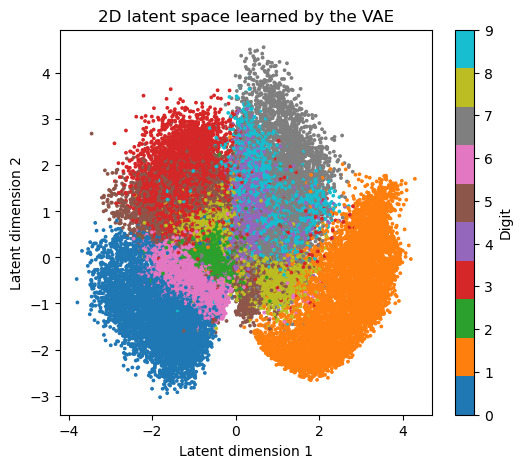

In [10]:
plt.figure(figsize=(6, 5))
plt.scatter(z[:, 0], z[:, 1], c=y, s=3, cmap="tab10")
plt.colorbar(label="Digit")
plt.xlabel("Latent dimension 1")
plt.ylabel("Latent dimension 2")
plt.title("2D latent space learned by the VAE")
plt.show()

7) Generate new digits

In [13]:
with torch.no_grad():
    # Sample from prior p(z) = N(0, I)
    z_samples = torch.randn(16, 2)

    # Decode to images
    generated = model.decode(z_samples)

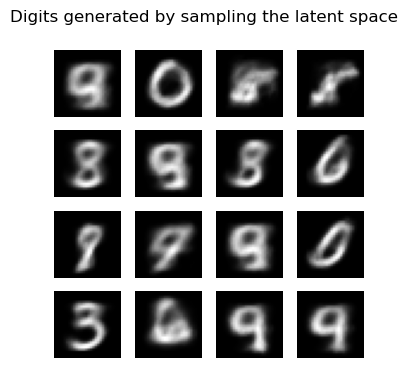

In [14]:
plt.figure(figsize=(4, 4))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated[i].view(28, 28).cpu(), cmap="gray")
    plt.axis("off")

plt.suptitle("Digits generated by sampling the latent space")
plt.show()